Fetch Take Home Exam

In [7]:
### install packages
%pip install pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [8]:
###import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [9]:
### Define the File Path
user_file_path='https://fetch-hiring.s3.amazonaws.com/data-analyst/da_take_home/USER_TAKEHOME.csv'
transaction_file_path='https://fetch-hiring.s3.amazonaws.com/data-analyst/da_take_home/TRANSACTION_TAKEHOME.csv'
product_file_path='https://fetch-hiring.s3.amazonaws.com/data-analyst/da_take_home/PRODUCTS_TAKEHOME.csv'


### read the csv file 
user_df=pd.read_csv(user_file_path) 
transaction_df=pd.read_csv(transaction_file_path) 
product_df=pd.read_csv(product_file_path) 


In [10]:
#Dataset Exploration

In [11]:
### User Data Quality Check
user_df.head()

,ID,CREATED_DATE,BIRTH_DATE,STATE,LANGUAGE,GENDER
0,5ef3b4f17053ab141787697d,2020-06-24 20:17:54.000 Z,2000-08-11 00:00:00.000 Z,CA,es-419,female
1,5ff220d383fcfc12622b96bc,2021-01-03 19:53:55.000 Z,2001-09-24 04:00:00.000 Z,PA,en,female
2,6477950aa55bb77a0e27ee10,2023-05-31 18:42:18.000 Z,1994-10-28 00:00:00.000 Z,FL,es-419,female
3,658a306e99b40f103b63ccf8,2023-12-26 01:46:22.000 Z,NaN,NC,en,NaN
4,653cf5d6a225ea102b7ecdc2,2023-10-28 11:51:50.000 Z,1972-03-19 00:00:00.000 Z,PA,en,female


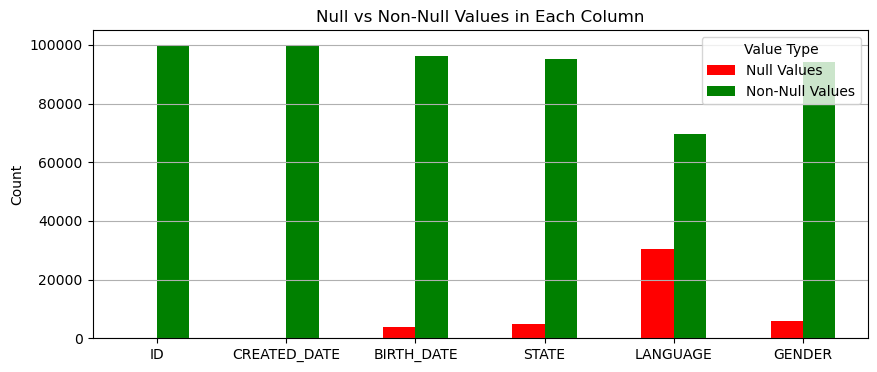

In [12]:
###check nulls

##first replace any blank with null
user_df.replace(" ", None, inplace=True)

null_cnt=user_df.isnull().sum()
notnull_cnt=user_df.notnull().sum()

# Create a DataFrame for plotting
null_check = pd.DataFrame({'Null Values': null_cnt, 'Non-Null Values': notnull_cnt})

null_check.plot(kind='bar', figsize=(10, 4), color=['red', 'green'])
plt.title('Null vs Non-Null Values in Each Column')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Value Type')
plt.grid(axis='y')
plt.show()

User ID Duplicate Count: 0


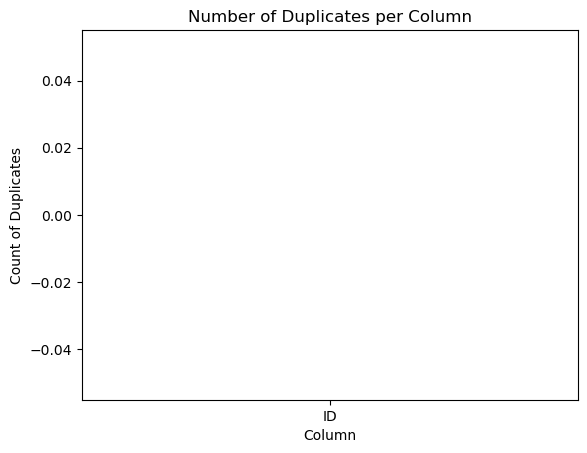

In [13]:
#This is user dataset, so all ids should be unique
duplicates = user_df['ID'].duplicated()

print("User ID Duplicate Count:", len(user_df[duplicates].index))


columns_to_check= ['ID']                                                    
dup_counts = {col: user_df.duplicated(subset=[col]).sum() for col in columns_to_check}
                                                      
sns.barplot(x=list(dup_counts.keys()), y=list(dup_counts.values()))
plt.title('Number of Duplicates per Column')
plt.ylabel('Count of Duplicates')
plt.xlabel('Column')
plt.show()


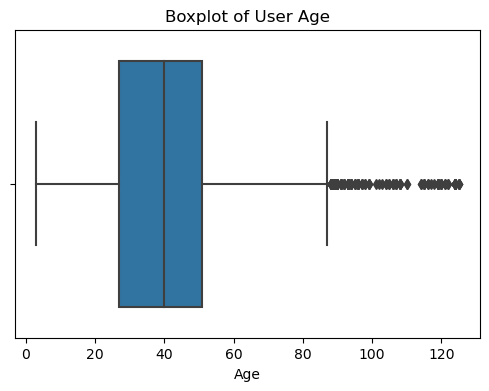

In [14]:
### use user birthday to calculate their age and check any outliers

#Calculate current year
current_date = datetime.now()
current_year = current_date.year

# Calculate age
user_df['BIRTH_DATE'] = pd.to_datetime(user_df['BIRTH_DATE'])
user_df['User_Age'] = current_year - user_df['BIRTH_DATE'].dt.year


plt.figure(figsize=(6, 4))
sns.boxplot(x=user_df['User_Age'])
plt.title('Boxplot of User Age')
plt.xlabel('Age')
plt.show()

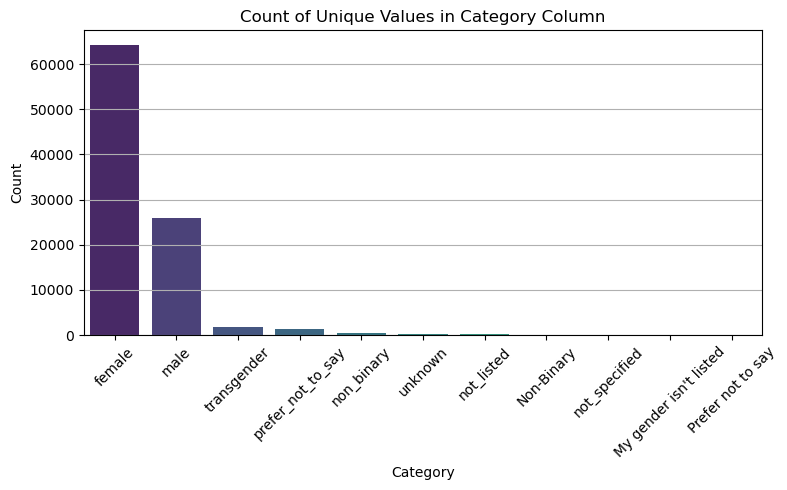

In [15]:
# Check the count for each unique value in gender column
value_counts = user_df['GENDER'].value_counts()


plt.figure(figsize=(8, 5))
sns.barplot(x=value_counts.index, y=value_counts.values, palette='viridis')
plt.title('Count of Unique Values in Category Column')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [16]:
### transaction Data Quality Check
transaction_df.head()

,RECEIPT_ID,PURCHASE_DATE,SCAN_DATE,STORE_NAME,USER_ID,BARCODE,FINAL_QUANTITY,FINAL_SALE
0,0000d256-4041-4a3e-adc4-5623fb6e0c99,2024-08-21,2024-08-21 14:19:06.539 Z,WALMART,63b73a7f3d310dceeabd4758,1.530001e+10,1.00,
1,0001455d-7a92-4a7b-a1d2-c747af1c8fd3,2024-07-20,2024-07-20 09:50:24.206 Z,ALDI,62c08877baa38d1a1f6c211a,NaN,zero,1.49
2,00017e0a-7851-42fb-bfab-0baa96e23586,2024-08-18,2024-08-19 15:38:56.813 Z,WALMART,60842f207ac8b7729e472020,7.874223e+10,1.00,
3,000239aa-3478-453d-801e-66a82e39c8af,2024-06-18,2024-06-19 11:03:37.468 Z,FOOD LION,63fcd7cea4f8442c3386b589,7.833997e+11,zero,3.49
4,00026b4c-dfe8-49dd-b026-4c2f0fd5c6a1,2024-07-04,2024-07-05 15:56:43.549 Z,RANDALLS,6193231ae9b3d75037b0f928,4.790050e+10,1.00,


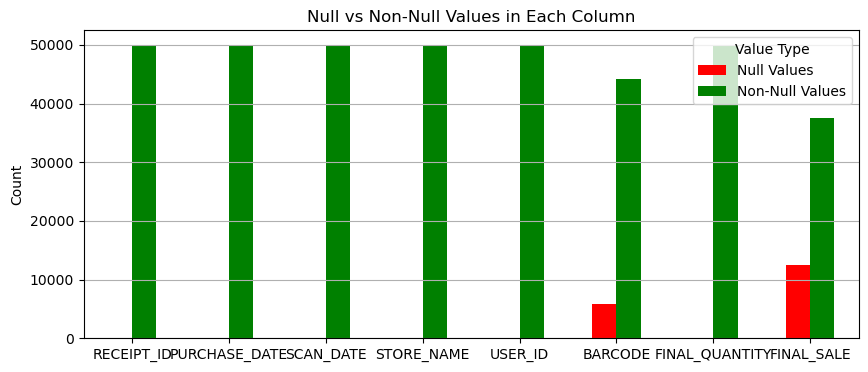

In [17]:
### User data quality check

###check nulls
##first replace any blank with null
transaction_df.replace(" ", None, inplace=True)

null_cnt=transaction_df.isnull().sum()
notnull_cnt=transaction_df.notnull().sum()

# Create a DataFrame for plotting
null_check = pd.DataFrame({'Null Values': null_cnt, 'Non-Null Values': notnull_cnt})

null_check.plot(kind='bar', figsize=(10, 4), color=['red', 'green'])
plt.title('Null vs Non-Null Values in Each Column')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Value Type')
plt.grid(axis='y')
plt.show()

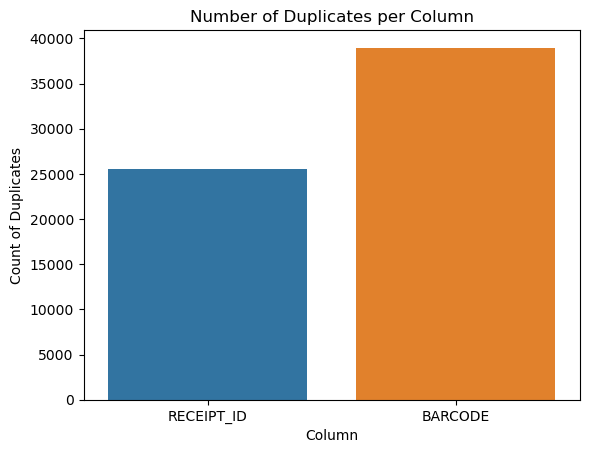

In [18]:
###This dataset looks like the transaction data, then RECEIPT_ID and barcode group should be unique

columns_to_check=['RECEIPT_ID','BARCODE']

# Count duplicates for each selected column
dup_counts = {col: transaction_df.duplicated(subset=[col]).sum() for col in columns_to_check}

# Plot
sns.barplot(x=list(dup_counts.keys()), y=list(dup_counts.values()))
plt.title('Number of Duplicates per Column')
plt.ylabel('Count of Duplicates')
plt.xlabel('Column')
plt.show()

In [19]:
### There are duplicates in RECEIPT_ID
### RECEIPT_ID should be 1:1 mapping to BARCODE and STORE_NAME

mapping_check_A = transaction_df['RECEIPT_ID'].value_counts()
mapping_check_B = transaction_df['USER_ID'].value_counts()

is_one_to_one = len(mapping_check_A) == len(mapping_check_B) and all(mapping_check_A == 1) and all(mapping_check_B == 1)

if is_one_to_one:
    print("\nThe mapping is one-to-one.")
else:
    print("\nThe mapping is NOT one-to-one.")



The mapping is NOT one-to-one.


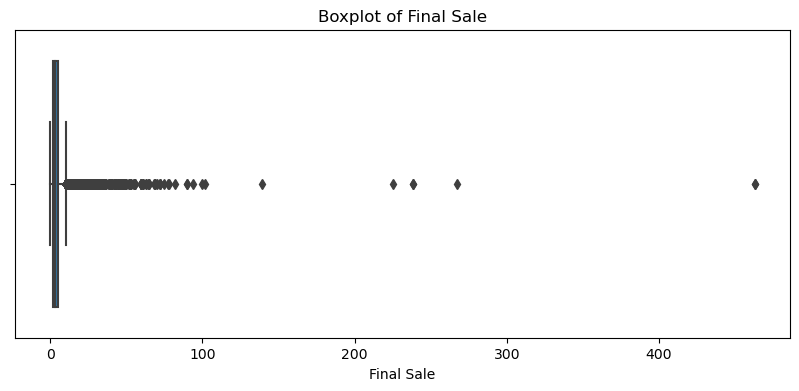

In [20]:
### use user birthday to calculate their age and check any outliers

plt.figure(figsize=(10, 4))
sns.boxplot(x=transaction_df['FINAL_SALE'].astype(float))
plt.title('Boxplot of Final Sale')
plt.xlabel('Final Sale')
plt.show()

In [21]:
### Product Data Quality Check
product_df.head()

,CATEGORY_1,CATEGORY_2,CATEGORY_3,CATEGORY_4,MANUFACTURER,BRAND,BARCODE
0,Health & Wellness,Sexual Health,Conductivity Gels & Lotions,NaN,NaN,NaN,7.964944e+11
1,Snacks,Puffed Snacks,Cheese Curls & Puffs,NaN,NaN,NaN,2.327801e+10
2,Health & Wellness,Hair Care,Hair Care Accessories,NaN,PLACEHOLDER MANUFACTURER,ELECSOP,4.618178e+11
3,Health & Wellness,Oral Care,Toothpaste,NaN,COLGATE-PALMOLIVE,COLGATE,3.500047e+10
4,Health & Wellness,Medicines & Treatments,Essential Oils,NaN,MAPLE HOLISTICS AND HONEYDEW PRODUCTS INTERCHA...,MAPLE HOLISTICS,8.068109e+11


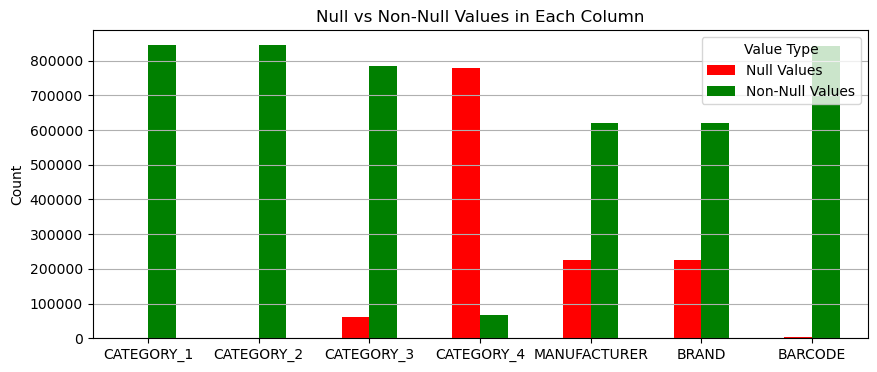

In [22]:
### User data quality check

###check nulls
##first replace any blank with null
product_df.replace(" ", None, inplace=True)

null_cnt=product_df.isnull().sum()
notnull_cnt=product_df.notnull().sum()

# Create a DataFrame for plotting
null_check = pd.DataFrame({'Null Values': null_cnt, 'Non-Null Values': notnull_cnt})

null_check.plot(kind='bar', figsize=(10, 4), color=['red', 'green'])
plt.title('Null vs Non-Null Values in Each Column')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Value Type')
plt.grid(axis='y')
plt.show()

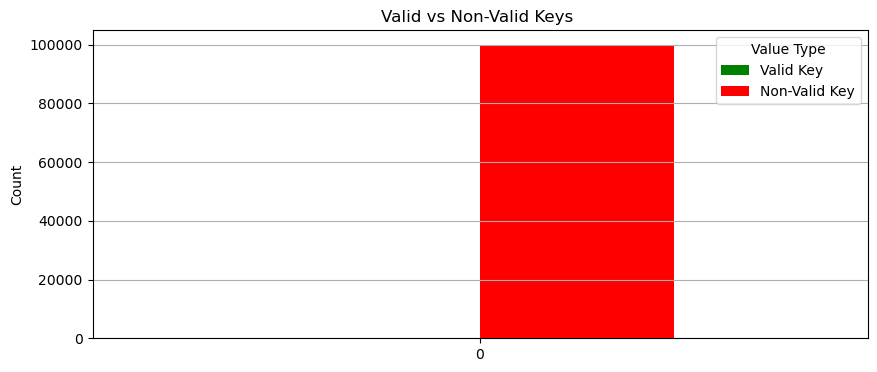

In [23]:
### validate relationships for these 3 tables
valid_keys=user_df['ID'].isin(transaction_df['USER_ID'])


valid_key=len(user_df.loc[valid_keys].index)
non_valid_key=len(user_df.index)-valid_key

# Create a DataFrame for plotting
valid_key_check = pd.DataFrame({'Valid Key': valid_key, 'Non-Valid Key': non_valid_key},index=[0])

valid_key_check.plot(kind='bar', figsize=(10, 4), color=['green', 'red'])
plt.title('Valid vs Non-Valid Keys ')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Value Type')
plt.grid(axis='y')
plt.show()


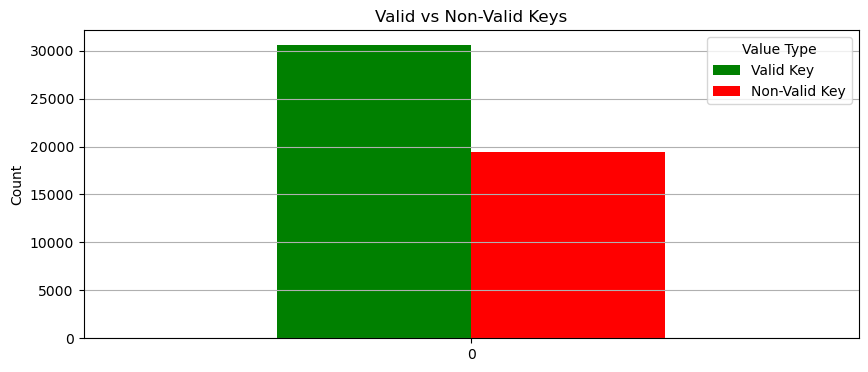

In [25]:
### validate relationships for these 3 tables
valid_keys=transaction_df['BARCODE'].isin(product_df['BARCODE'])

valid_key=len(transaction_df.loc[valid_keys].index)
non_valid_key=len(transaction_df.index)-valid_key

# Create a DataFrame for plotting
valid_key_check = pd.DataFrame({'Valid Key': valid_key, 'Non-Valid Key': non_valid_key},index=[0])

valid_key_check.plot(kind='bar', figsize=(10, 4), color=['green', 'red'])
plt.title('Valid vs Non-Valid Keys')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Value Type')
plt.grid(axis='y')
plt.show()


Data Quality Issues

User Dataset:
1. Missing Values: There are null values present in the columns 'BIRTH_DATE', 'STATE', 'LANGUAGE', and 'GENDER'. Notably, approximately one-third of the entries in 'LANGUAGE' are null, while 'BIRTH_DATE', 'STATE', and 'GENDER' each have around 5% missing values. Without accurate information regarding customers' birth dates, states, and genders, we risk lacking a comprehensive understanding of our customer demographics.
2. Invalid entries in 'GENDER' column :  We have 'unknown','not_listed','not_specified','my gender isn't listed' in 'GENDER' column. 
3. Outliers in 'Birthday' column: The 'User_Age' field contains outliers, with recorded ages ranging from newborns to individuals over 120 years old. This suggests inaccuracies in the birth dates recorded for some customers, indicating that manual input may have led to erroneous data.

Transaction Dataset:
1. Missing Values: The columns 'BARCODE' and 'FINAL_SALE' include null values, with approximately 10% of 'BARCODE' entries and 25% of 'FINAL_SALE' values being absent.
2. Duplicate Records: Duplicates have been identified in 'RECEIPT_ID' and 'BARCODE'. This implies that customers may scan the same receipt multiple times, necessitating the removal of invalid records for accurate analysis.


Product Dataset:
1. Missing Values: There are nulls in 'CATEGORY_3', 'CATEGORY_4', 'MANUFACTURER', 'BRAND', and 'BARCODE'. The 'CATEGORY_4' field has nearly 90% missing values, while 'MANUFACTURER' and 'BRAND' include over 25% nulls, and 'CATEGORY_3' has about 10% missing values. The high percentage of nulls in 'CATEGORY_4' may be understandable due to limited product categorization. However, the absence of 'MANUFACTURER' and 'BRAND' data hinders our ability to identify popular brands and manufacturers among our customers, potentially impacting our marketing strategies.
   
Relationships Between Datasets:
1. User and Transaction Datasets: The primary key for joining the User table and Transaction table is 'user_id'. However, many IDs present in the User dataset do not appear in the Transaction table, leading to incomplete connections.
2. Transaction and Product Datasets: 'BARCODE' serves as the linking key between the Transaction and Product tables. Due to the presence of nulls and data inconsistencies, only about 30,000 unique barcodes from the Transaction table are successfully matched to products.

Challenges in Understanding Fields

User Dataset:
1. Lack of Context: It is unclear which fields are automatically generated by the system versus those that are input by customers.
2. Language Code Ambiguity: The meaning of the code 'es-419' is not defined within the dataset, leading to confusion regarding its significance.
3. 
Transaction Dataset:
1. Lack of Context: Similar to the User dataset, there is ambiguity regarding which fields are system-generated and which are customer inputs.
2. Inconsistent Data Entries: I observed that a single receipt_id has the same purchase date and scan date, yet contains multiple records—one record shows a final sale amount while another does not. This inconsistency raises questions about data integrity.
   
Product Dataset:
1. Lack of Context: As with the previous datasets, it is unclear which fields are generated automatically by the system and which are user-generated.